# Execution Strategy Comparison — DA Positioning Signal

Holding entry signals fixed from notebook 01 (Section 4 best run, selected by **Calmar Ratio → Sharpe → Profit Factor → Return**), this notebook isolates the **execution layer** and answers a core trading question: *given an open DA position, which exit mechanism delivers the best risk-adjusted P&L?*

Four archetypes are tested across return, risk, and consistency dimensions:

| Strategy | Passive Fraction | Active Gate | Terminal Settlement |
|---|---|---|---|
| **Settlement Only** | 0% | — | 100% rides to SSP/SBP imbalance |
| **Full MID Hedge** | 100% | — | 100% exits at intraday mid-market |
| **Active Gate Only** | 0% | TP/SL | MID on trigger; imbalance fallback |
| **Hybrid (50/50)** | 50% | TP/SL | 50% passive MID + 50% active gate |

All four share identical signals. Every performance difference is attributable solely to the exit mechanism.

**Decision criterion applied throughout:** Calmar Ratio (primary) → Sharpe → Profit Factor → Total Return. The hedge ratio sensitivity sweep (Section 4) and decision framework (Section 8) use this same priority.

In [42]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
sys.path.insert(0, str(REPO_ROOT))

from src.backtest.engine import run_backtest_from_dataframe

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

STARTING_CAPITAL = 50_000.0
ARTIFACT_DIR = REPO_ROOT / "artifacts" / "da_positioning" / "s4_n5_t30_tc10"

In [43]:
features = pd.read_parquet(ARTIFACT_DIR / "features" / "features.parquet")
signals = pd.read_csv(ARTIFACT_DIR / "virtual" / "trading" / "signals.csv", parse_dates=["delivery_time"])

signals["delivery_time"] = pd.to_datetime(signals["delivery_time"], utc=True)

bt_df = features[["time", "day_ahead_price", "system_sell_price", "system_buy_price", "mid_price"]].copy()
bt_df = bt_df.merge(
    signals[["delivery_time", "signal", "predicted_spread"]].rename(columns={"delivery_time": "time"}),
    on="time",
    how="inner",
)

COMMON_KW = dict(
    signal_col="signal",
    da_price_col="day_ahead_price",
    sell_price_col="system_sell_price",
    buy_price_col="system_buy_price",
    time_col="time",
    starting_capital=STARTING_CAPITAL,
    cost_per_trade=1.00,  # TC = £1.00/MWh — consistent with notebook 01 Section 4 best-run tier
)

STRATEGIES = {
    "Settlement Only":  dict(mid_price_col=None,        predicted_spread_col=None,                baseline_hedge_ratio=0.0),
    "Full MID Hedge":   dict(mid_price_col="mid_price", predicted_spread_col="predicted_spread", baseline_hedge_ratio=1.0),
    "Active Gate Only": dict(mid_price_col="mid_price", predicted_spread_col="predicted_spread", baseline_hedge_ratio=0.0),
    "Hybrid (50/50)":   dict(mid_price_col="mid_price", predicted_spread_col="predicted_spread", baseline_hedge_ratio=0.5),
}

results = {}
for name, kw in STRATEGIES.items():
    df_out, metrics = run_backtest_from_dataframe(bt_df.copy(), **COMMON_KW, **kw)
    results[name] = {"pnl": df_out[["time", "pnl"]], "metrics": metrics}

print("Backtests complete (TC = £1.00/MWh):")
for name, r in results.items():
    m = r["metrics"]
    print(f"  {name:.<30s} Total PnL: £{m['total_pnl']:>10,.0f}  |  Sharpe: {m['sharpe_ratio']:.3f}")

Backtests complete (TC = £1.00/MWh):
  Settlement Only............... Total PnL: £    93,071  |  Sharpe: 3.407
  Full MID Hedge................ Total PnL: £    37,575  |  Sharpe: 3.326
  Active Gate Only.............. Total PnL: £    51,353  |  Sharpe: 3.149
  Hybrid (50/50)................ Total PnL: £    44,443  |  Sharpe: 3.454


---
## 1. Comparative Equity Curve

All four strategies start from the same £50k capital and use identical entry signals. Differences in the curves are driven entirely by the exit mechanism — demonstrating the value (or cost) of each execution layer.

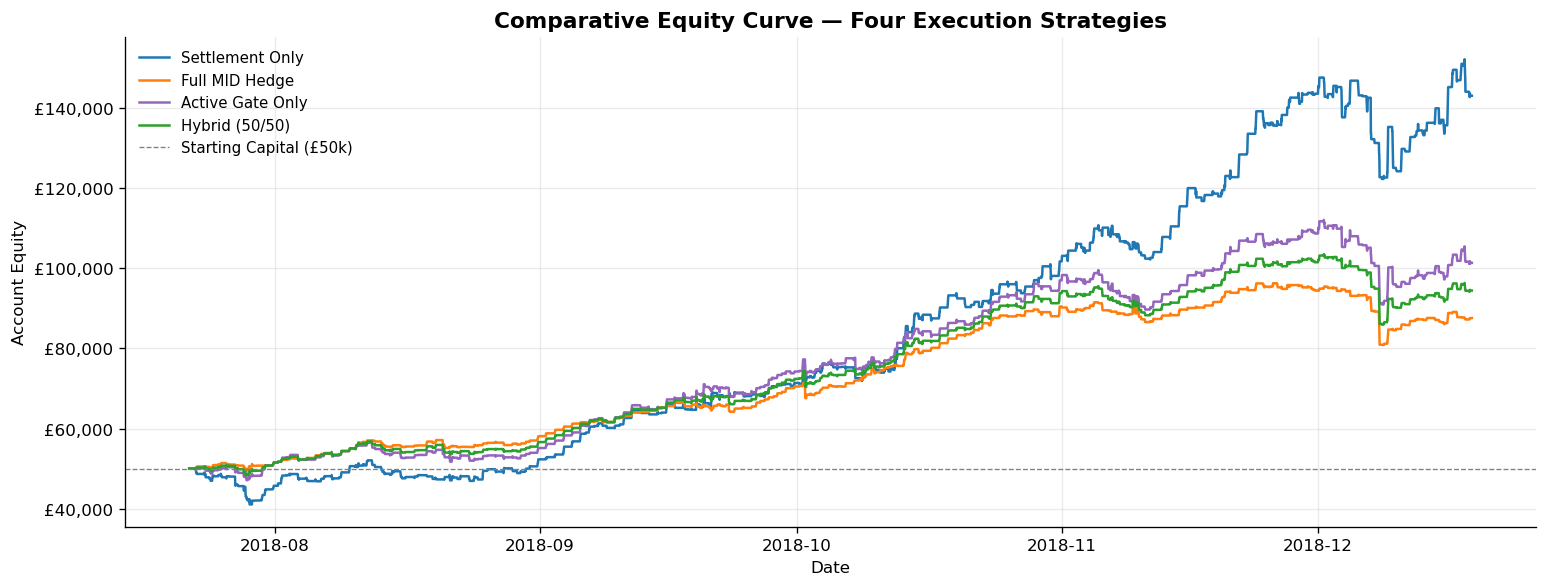

In [44]:
COLORS = {
    "Settlement Only":  "#1f77b4",
    "Full MID Hedge":   "#ff7f0e",
    "Active Gate Only": "#9467bd",
    "Hybrid (50/50)":   "#2ca02c",
}

fig, ax = plt.subplots(figsize=(13, 5))

for name, r in results.items():
    pnl_df = r["pnl"]
    equity = STARTING_CAPITAL + pnl_df["pnl"].cumsum()
    ax.plot(pnl_df["time"], equity, label=name, color=COLORS[name], linewidth=1.5)

ax.axhline(STARTING_CAPITAL, color="grey", linestyle="--", linewidth=0.8, label="Starting Capital (£50k)")
ax.set_title("Comparative Equity Curve — Four Execution Strategies", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Account Equity")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

---
## 2. Performance Tear Sheet

Side-by-side comparison of headline risk/return metrics across all four execution strategies. Total Return, Max Drawdown, and Sharpe Ratio are the key decision metrics.

In [45]:
rows = []
for name, r in results.items():
    m = r["metrics"]
    pnl_series = r["pnl"]["pnl"]

    max_dd_pct = abs(m["max_drawdown"]) / STARTING_CAPITAL
    calmar = m["total_return_pct"] / max_dd_pct if max_dd_pct > 0 else float("nan")
    n_trades = m.get("n_trades", int((pnl_series != 0).sum()))
    avg_trade = m["total_pnl"] / n_trades if n_trades > 0 else float("nan")

    rows.append({
        "Strategy":       name,
        "Total PnL":      f"£{m['total_pnl']:,.0f}",
        "Total Return":   f"{m['total_return_pct']:.1%}",
        "Sharpe":         f"{m['sharpe_ratio']:.3f}",
        "Calmar":         f"{calmar:.2f}",
        "Max Drawdown":   f"£{m['max_drawdown']:,.0f}",
        "Max DD %":       f"{max_dd_pct:.1%}",
        "Win Rate":       f"{m['win_rate']:.1%}",
        "Profit Factor":  f"{m['profit_factor']:.2f}",
        "N Trades":       f"{n_trades:,}",
        "Avg Trade (£)":  f"£{avg_trade:,.2f}",
    })

tear_df = pd.DataFrame(rows).set_index("Strategy")
tear_df.style.set_properties(**{"text-align": "right"})

,Total PnL,Total Return,Sharpe,Calmar,Max Drawdown,Max DD %,Win Rate,Profit Factor,N Trades,Avg Trade (£)
Strategy,,,,,,,,,,
Settlement Only,"£93,071",186.1%,3.407,3.68,"£-25,304",50.6%,52.9%,1.43,976,£95.36
Full MID Hedge,"£37,575",75.1%,3.326,2.43,"£-15,445",30.9%,64.0%,1.54,976,£38.50
Active Gate Only,"£51,353",102.7%,3.149,2.43,"£-21,110",42.2%,61.3%,1.35,976,£52.62
Hybrid (50/50),"£44,443",88.9%,3.454,2.53,"£-17,545",35.1%,62.4%,1.44,976,£45.54


---
## 3. Risk vs. Reward — Efficient Frontier

Maximum Drawdown (X-axis, smaller to larger — lower risk on the left) plotted against Total PnL (Y-axis). Strategies in the upper-left quadrant offer higher return for lower drawdown — the efficient frontier of execution design.

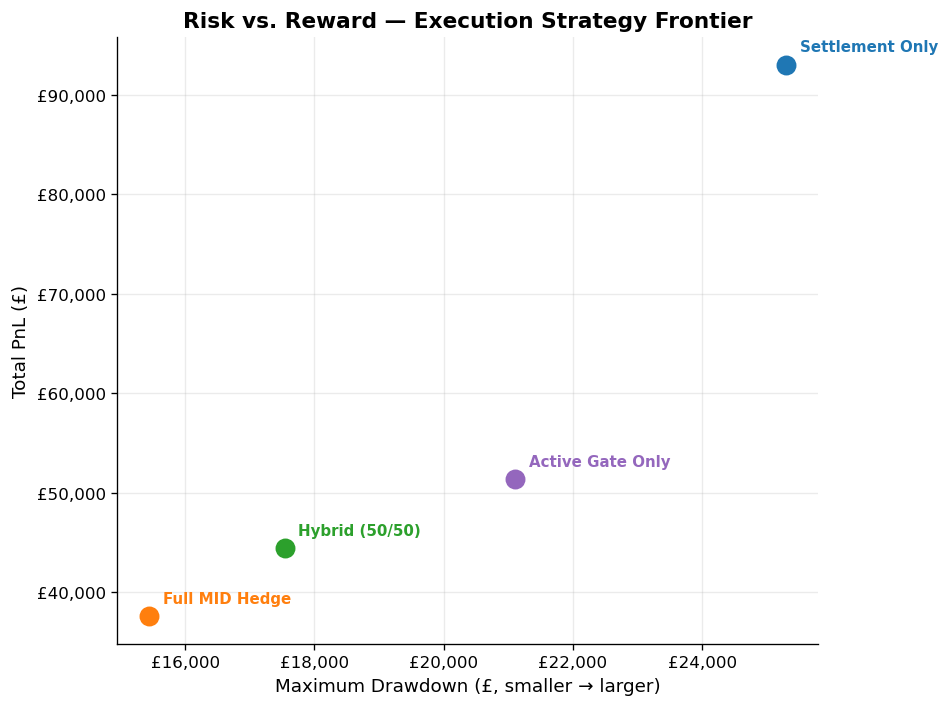

In [46]:
fig, ax = plt.subplots(figsize=(8, 6))

for name, r in results.items():
    m = r["metrics"]
    dd = abs(m["max_drawdown"])
    pnl = m["total_pnl"]
    ax.scatter(dd, pnl, s=120, color=COLORS[name], zorder=5)
    ax.annotate(
        name, (dd, pnl),
        textcoords="offset points", xytext=(8, 8),
        fontsize=9, color=COLORS[name], fontweight="bold",
    )

ax.set_xlabel("Maximum Drawdown (£, smaller → larger)", fontsize=11)
ax.set_ylabel("Total PnL (£)", fontsize=11)
ax.set_title("Risk vs. Reward — Execution Strategy Frontier", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
plt.tight_layout()
plt.show()

---
## 4. Hedge Ratio Sensitivity

How does the passive fraction (`baseline_hedge_ratio`) affect risk and return? This sweep holds all other parameters constant — identical signals, TC = £1.00/MWh, same TP/SL gate — and varies only the proportion allocated to passive MID exit.

A ratio of 0.0 routes all volume through the active TP/SL gate (imbalance as terminal fallback); 1.0 routes everything to passive MID with no active gate. Hybrid (50/50) sits at 0.5, marked by the dashed line. The Calmar and Sharpe curves identify the optimal ratio for risk-adjusted return given this signal set.

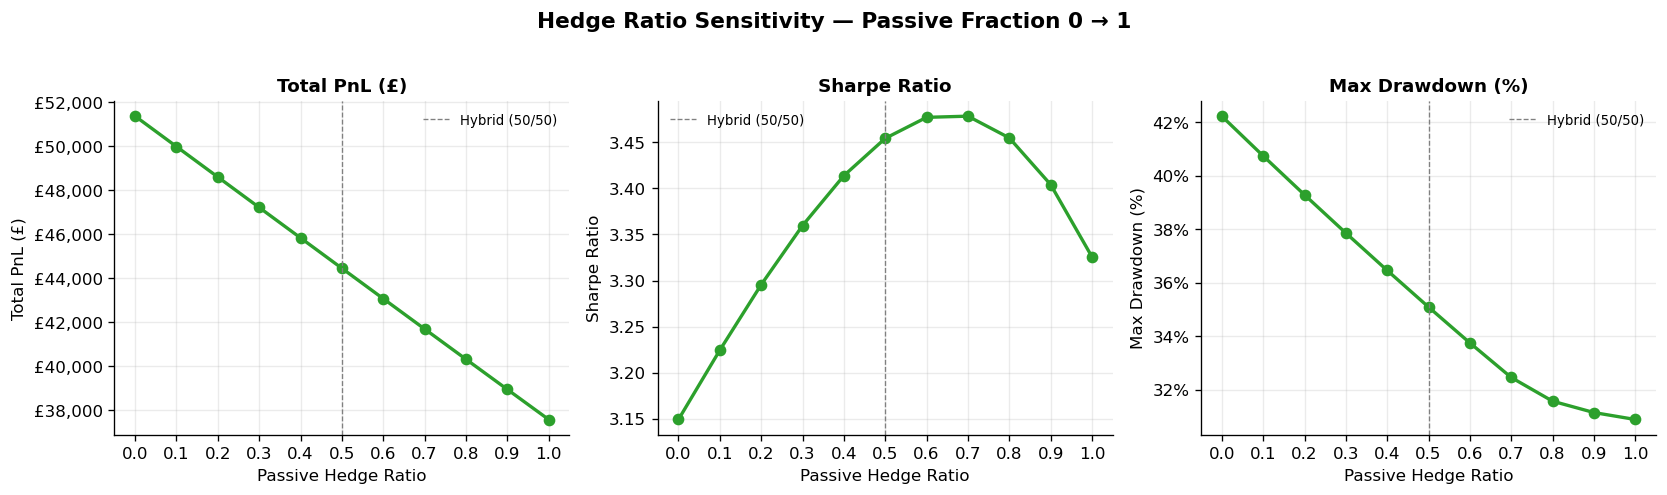

In [47]:
HEDGE_RATIOS = np.round(np.arange(0.0, 1.1, 0.1), 1)
sweep_records = []

for ratio in HEDGE_RATIOS:
    kw = dict(
        mid_price_col="mid_price",
        predicted_spread_col="predicted_spread",
        baseline_hedge_ratio=ratio,
    )
    _, m = run_backtest_from_dataframe(bt_df.copy(), **COMMON_KW, **kw)
    max_dd_pct = abs(m["max_drawdown"]) / STARTING_CAPITAL
    sweep_records.append({
        "ratio":     ratio,
        "total_pnl": m["total_pnl"],
        "sharpe":    m["sharpe_ratio"],
        "max_dd_pct": max_dd_pct,
        "calmar":    m["total_return_pct"] / max_dd_pct if max_dd_pct > 0 else np.nan,
    })

sweep_df = pd.DataFrame(sweep_records)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, (col, ylabel, formatter) in zip(axes, [
    ("total_pnl",  "Total PnL (£)",      lambda x, _: f"£{x:,.0f}"),
    ("sharpe",     "Sharpe Ratio",        None),
    ("max_dd_pct", "Max Drawdown (%)",    lambda x, _: f"{x:.0%}"),
]):
    ax.plot(sweep_df["ratio"], sweep_df[col], marker="o", linewidth=2, color="#2ca02c")
    ax.axvline(0.5, color="grey", linestyle="--", linewidth=0.8, label="Hybrid (50/50)")
    ax.set_xlabel("Passive Hedge Ratio")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel, fontsize=11, fontweight="bold")
    ax.set_xticks(HEDGE_RATIOS)
    if formatter:
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(formatter))
    ax.legend(frameon=False, fontsize=8)

plt.suptitle("Hedge Ratio Sensitivity — Passive Fraction 0 → 1", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---
## 5. Monthly PnL Breakdown

Monthly P&L grouped by calendar month reveals where each strategy makes and loses money across the year. Strategies with heavy imbalance exposure tend to have more concentrated loss months; passive MID exit flattens the distribution at the cost of absolute return. A good exit mechanism produces consistent positive months — not a single lucky quarter.

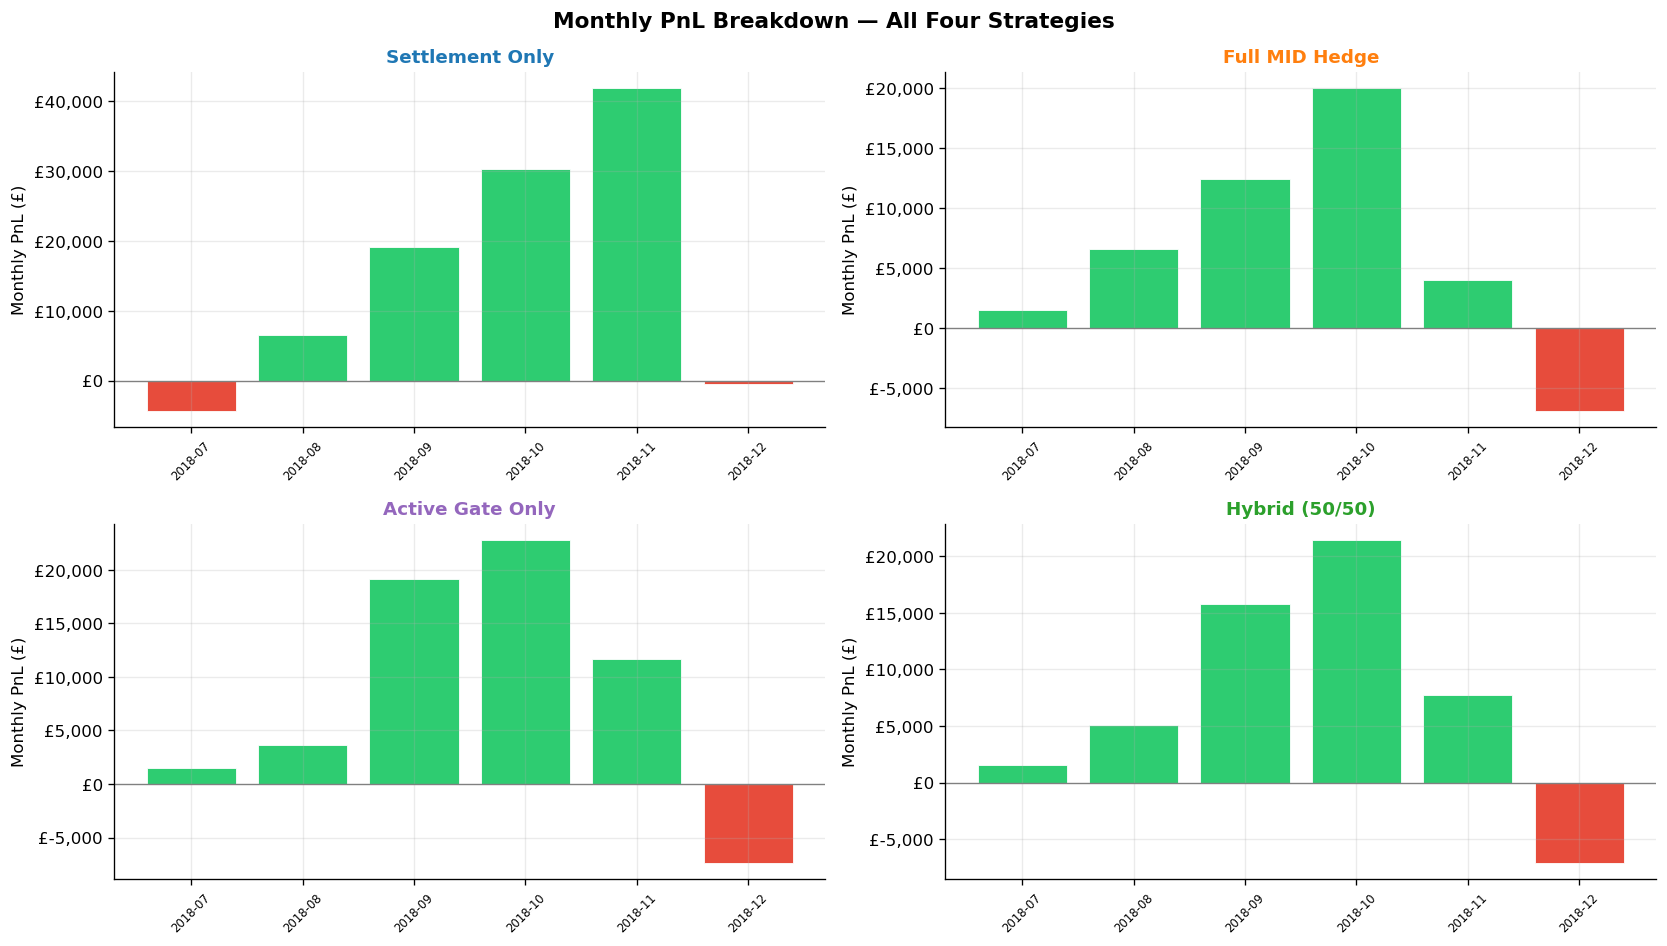

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (name, r) in zip(axes, results.items()):
    pnl_df = r["pnl"].copy()
    pnl_df["month"] = pd.to_datetime(pnl_df["time"]).dt.to_period("M")
    monthly = pnl_df.groupby("month")["pnl"].sum().reset_index()
    monthly["month_str"] = monthly["month"].astype(str)
    bar_colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in monthly["pnl"]]
    ax.bar(monthly["month_str"], monthly["pnl"], color=bar_colors, edgecolor="white", linewidth=0.5)
    ax.axhline(0, color="grey", linewidth=0.8)
    ax.set_title(name, fontsize=11, fontweight="bold", color=COLORS[name])
    ax.set_ylabel("Monthly PnL (£)")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
    ax.tick_params(axis="x", rotation=45, labelsize=7)

plt.suptitle("Monthly PnL Breakdown — All Four Strategies", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---
## 6. Rolling Sharpe — Regime Stability

A 30-day rolling annualised Sharpe distinguishes *consistently* high-Sharpe strategies from those that produce a strong full-year number through a concentrated burst. Strategies that hold a positive Sharpe across most rolling windows are more robust to regime shifts and less likely to blow up during a quiet imbalance period.

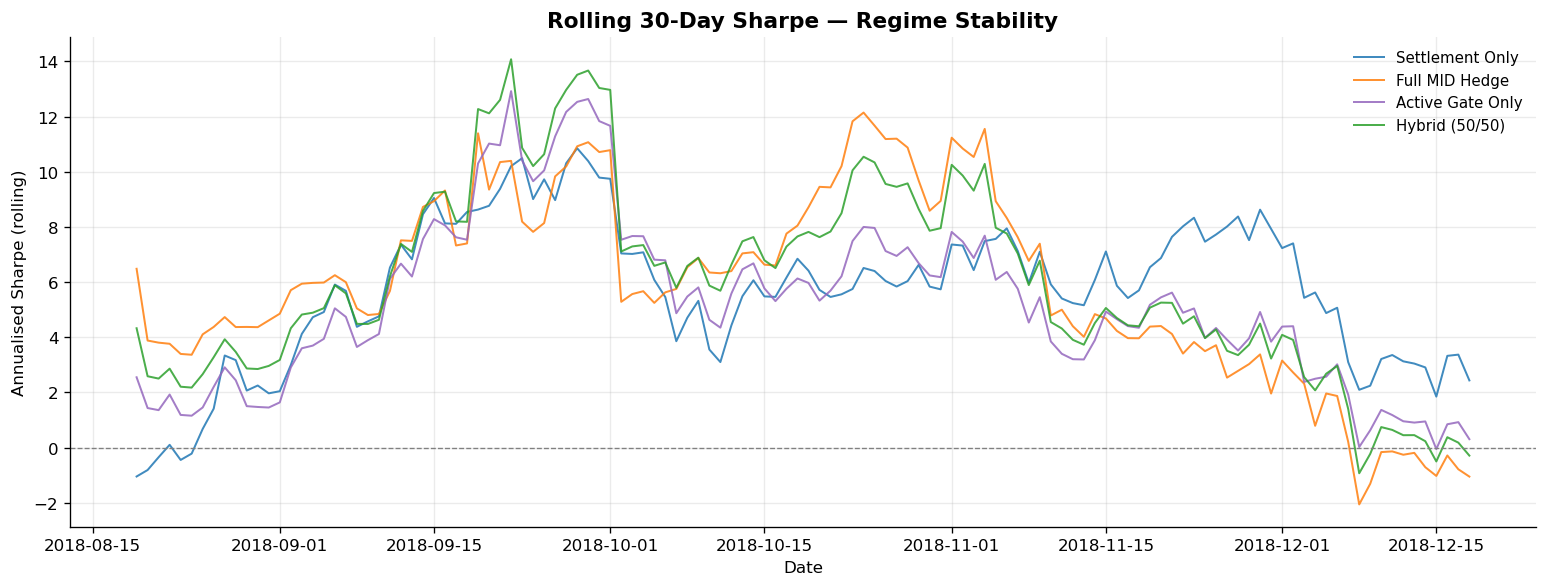

In [49]:
ROLLING_WINDOW = 30  # calendar days

fig, ax = plt.subplots(figsize=(13, 5))

for name, r in results.items():
    pnl_df = r["pnl"].copy()
    pnl_df = pnl_df.set_index("time").sort_index()
    daily_pnl = pnl_df["pnl"].resample("D").sum()
    rolling_sharpe = (
        daily_pnl.rolling(ROLLING_WINDOW).mean()
        / daily_pnl.rolling(ROLLING_WINDOW).std()
        * np.sqrt(252)
    )
    ax.plot(rolling_sharpe.index, rolling_sharpe, label=name, color=COLORS[name], linewidth=1.2, alpha=0.85)

ax.axhline(0, color="grey", linestyle="--", linewidth=0.8)
ax.set_title(f"Rolling {ROLLING_WINDOW}-Day Sharpe — Regime Stability", fontsize=13, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Annualised Sharpe (rolling)")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

---
## 7. Execution Breakdown — Active Gate Routing

The stacked bar chart compares how the TP/SL gate classified active trades in the two strategies that use it. Settlement Only and Full MID Hedge have no active gate and are excluded.

Trigger counts are identical across Active Gate Only and Hybrid (50/50) because TP/SL decisions are price-driven, not volume-driven. The critical difference is *how much volume* each trigger moves: 100% of position in Active Gate Only vs. 50% in Hybrid. This is why Active Gate Only carries nearly double the drawdown despite the same trigger profile.

- **Take Profit** — intraday MID crossed the TP level; gains locked in early.
- **Stop Loss** — intraday loss exceeded the threshold; position cut at MID.
- **Settlement Fallback** — neither trigger fired within the delivery window; active slice settled at SSP/SBP.

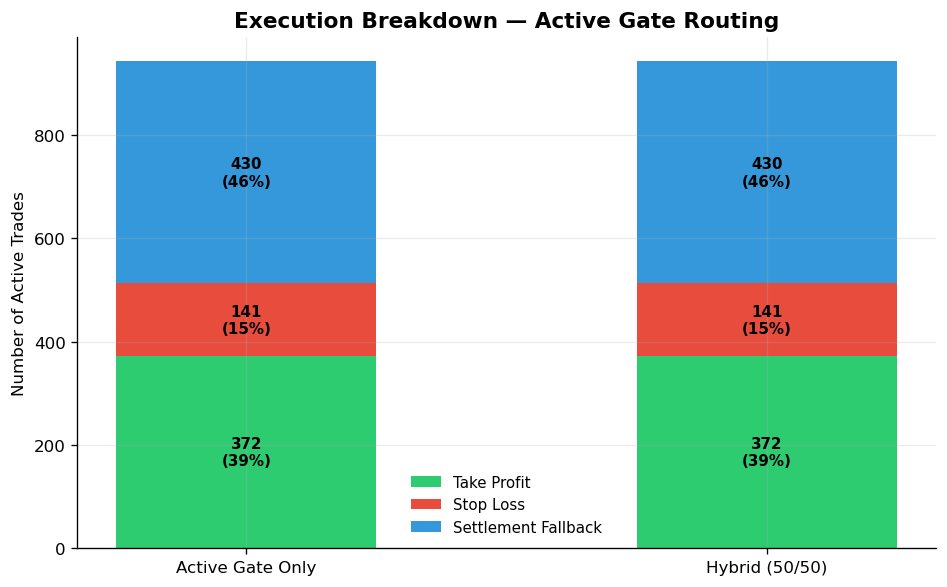

In [50]:
BREAKDOWN_STRATEGIES = ["Active Gate Only", "Hybrid (50/50)"]
EB_COLORS = {"Take Profit": "#2ecc71", "Stop Loss": "#e74c3c", "Settlement Fallback": "#3498db"}

fig, ax = plt.subplots(figsize=(8, 5))

x = np.arange(len(BREAKDOWN_STRATEGIES))
bar_width = 0.5
bottoms = np.zeros(len(BREAKDOWN_STRATEGIES))

for label, key in [
    ("Take Profit",         "active_tp_triggered"),
    ("Stop Loss",           "active_sl_triggered"),
    ("Settlement Fallback", "active_rode_to_imbalance"),
]:
    vals = np.array([results[s]["metrics"]["execution_breakdown"][key] for s in BREAKDOWN_STRATEGIES], dtype=float)
    ax.bar(x, vals, bar_width, bottom=bottoms, label=label, color=EB_COLORS[label])
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 0:
            total = sum(
                results[BREAKDOWN_STRATEGIES[i]]["metrics"]["execution_breakdown"][k]
                for k in ["active_tp_triggered", "active_sl_triggered", "active_rode_to_imbalance"]
            )
            pct = v / total if total > 0 else 0
            ax.text(i, b + v / 2, f"{int(v)}\n({pct:.0%})", ha="center", va="center", fontsize=9, fontweight="bold")
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(BREAKDOWN_STRATEGIES, fontsize=10)
ax.set_ylabel("Number of Active Trades")
ax.set_title("Execution Breakdown — Active Gate Routing", fontsize=13, fontweight="bold")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

---
## 8. Decision Framework

Quantified trade-offs between strategies, computed directly from backtest results. The key question is whether the reduction in drawdown that Hybrid buys over Settlement Only is worth the sacrifice in absolute return — and whether that calculus changes as account size grows.

In [51]:
# Decision framework — computed from backtest results
print("=" * 65)
print("EXECUTION STRATEGY DECISION FRAMEWORK")
print("=" * 65)

for name, r in results.items():
    m = r["metrics"]
    max_dd_pct = abs(m["max_drawdown"]) / STARTING_CAPITAL
    calmar = m["total_return_pct"] / max_dd_pct if max_dd_pct > 0 else float("nan")
    print(f"\n{name}")
    print(f"  Return:        {m['total_return_pct']:>+7.1%}")
    print(f"  Sharpe:        {m['sharpe_ratio']:>7.3f}")
    print(f"  Calmar:        {calmar:>7.2f}")
    print(f"  Max DD:        £{m['max_drawdown']:>10,.0f}  ({max_dd_pct:.1%} of starting capital)")
    print(f"  Win Rate:      {m['win_rate']:>7.1%}")
    print(f"  Profit Factor: {m['profit_factor']:>7.2f}")

print()
print("-" * 65)

# Quantify the Settlement Only → Hybrid trade-off
so  = results["Settlement Only"]["metrics"]
hyb = results["Hybrid (50/50)"]["metrics"]
so_dd  = abs(so["max_drawdown"])  / STARTING_CAPITAL
hyb_dd = abs(hyb["max_drawdown"]) / STARTING_CAPITAL
dd_reduction  = (so_dd  - hyb_dd)  / so_dd
pnl_sacrifice = (so["total_pnl"] - hyb["total_pnl"]) / so["total_pnl"]

print(f"\nSettlement Only → Hybrid (50/50):")
print(f"  Drawdown reduced by {dd_reduction:.0%}  |  Return sacrificed: {pnl_sacrifice:.0%}")
print(f"\nFor a £{STARTING_CAPITAL:,.0f} account, switching to Hybrid")
print(f"  buys {dd_reduction:.0%} less drawdown exposure")
print(f"  at the cost of {pnl_sacrifice:.0%} of absolute return.")
print()
print("Path forward: as account grows and drawdown tolerance relaxes,")
print("lower baseline_hedge_ratio to recapture the return differential.")

EXECUTION STRATEGY DECISION FRAMEWORK

Settlement Only
  Return:        +186.1%
  Sharpe:          3.407
  Calmar:           3.68
  Max DD:        £   -25,304  (50.6% of starting capital)
  Win Rate:        52.9%
  Profit Factor:    1.43

Full MID Hedge
  Return:         +75.1%
  Sharpe:          3.326
  Calmar:           2.43
  Max DD:        £   -15,445  (30.9% of starting capital)
  Win Rate:        64.0%
  Profit Factor:    1.54

Active Gate Only
  Return:        +102.7%
  Sharpe:          3.149
  Calmar:           2.43
  Max DD:        £   -21,110  (42.2% of starting capital)
  Win Rate:        61.3%
  Profit Factor:    1.35

Hybrid (50/50)
  Return:         +88.9%
  Sharpe:          3.454
  Calmar:           2.53
  Max DD:        £   -17,545  (35.1% of starting capital)
  Win Rate:        62.4%
  Profit Factor:    1.44

-----------------------------------------------------------------

Settlement Only → Hybrid (50/50):
  Drawdown reduced by 31%  |  Return sacrificed: 52%

For a £

---
*Exit mechanism drives as much P&L dispersion as signal quality. Calibrate `baseline_hedge_ratio` against drawdown tolerance first — return differential can be recaptured by scaling position size as account equity grows.*